# TP2 — Aproximación de imágenes con algoritmos genéticos

Este notebook aproxima una imagen mediante **N triángulos** y un algoritmo genético mejorado.

Características principales:

- inicialización estructurada con colores tomados de la imagen;
- crossover por bloques completos de triángulos;
- mutaciones adaptativas de genes, vértices y color;
- evaluación progresiva a resolución creciente;
- elitismo e inyección de diversidad;
- refinamiento local mediante *hill climbing*;
- renderizado final con antialiasing.

El notebook está preparado para ejecutarse localmente en Jupyter, sin dependencias de Google Colab.


## 1. Dependencias

Las bibliotecas utilizadas deben estar instaladas en el entorno de Python asociado al kernel de Jupyter.


In [1]:
from pathlib import Path
import copy
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
from scipy import ndimage
from skimage.metrics import structural_similarity as ssim

warnings.filterwarnings("ignore")


## 2. Renderizado y métricas

Estas funciones convierten los genes en una imagen y calculan el error combinado de color, bordes y similitud estructural (SSIM).


In [2]:
def renderizar(triangulos, size=(100,100), fondo=(255,255,255,255)):
    """Renderiza los triángulos en una imagen del tamaño dado (sin antialiasing)."""
    img = Image.new('RGBA', size, fondo)
    draw = ImageDraw.Draw(img, 'RGBA')
    for pts, color in triangulos:
        x1,y1,x2,y2,x3,y3 = pts
        w,h = size
        p = [(int(x1*w), int(y1*h)),
             (int(x2*w), int(y2*h)),
             (int(x3*w), int(y3*h))]
        r,g,b,a = [int(c*255) for c in color]
        draw.polygon(p, fill=(r,g,b,a))
    return img

def renderizar_alta_resolucion(triangulos, size, supersample=2):
    """
    Renderiza con antialiasing mediante supersampling.
    - Dibuja a size * supersample y reduce con LANCZOS.
    """
    if supersample <= 1:
        return renderizar(triangulos, size)
    big_size = (size[0]*supersample, size[1]*supersample)
    big_img = renderizar(triangulos, big_size)
    # Reducir con LANCZOS (antialiasing de alta calidad)
    return big_img.resize(size, Image.LANCZOS)

def mse(im1, im2):
    a1 = np.array(im1.convert('RGB')).astype(np.float32)/255.0
    a2 = np.array(im2.convert('RGB')).astype(np.float32)/255.0
    return np.mean((a1-a2)**2)

def gradiente(im):
    sx = ndimage.sobel(im, axis=0)
    sy = ndimage.sobel(im, axis=1)
    return np.hypot(sx, sy)

def fitness_combinado(im_orig, im_rec, peso_bordes=0.15, peso_ssim=0.15):
    err_color = mse(im_orig, im_rec)

    gray_orig = np.array(im_orig.convert('L')).astype(np.float32)/255.0
    gray_rec = np.array(im_rec.convert('L')).astype(np.float32)/255.0

    g_orig = gradiente(gray_orig)
    g_rec = gradiente(gray_rec)
    g_orig = g_orig / (g_orig.max() + 1e-8)
    g_rec = g_rec / (g_rec.max() + 1e-8)
    err_bordes = np.mean((g_orig - g_rec)**2)

    try:
        ssim_val = ssim(gray_orig, gray_rec, data_range=1.0, win_size=7)
        err_ssim = 1.0 - ssim_val
    except:
        err_ssim = 0.0

    err_total = err_color + peso_bordes * err_bordes + peso_ssim * err_ssim
    return err_total

# ----------------------------------------------------------------------
# Generación de triángulos estructurados con colores desde la imagen
# ----------------------------------------------------------------------


## 3. Inicialización de los triángulos

La población inicial distribuye los triángulos sobre una grilla y toma sus colores de la imagen objetivo.


In [3]:
def generar_triangulos_grilla(n, target, perturbacion=0.12):
    """
    Genera n triángulos distribuidos en grilla.
    Cada triángulo cubre la mayor parte de su celda (se solapan ligeramente).
    El color se toma del centro de la celda en la imagen objetivo.
    """
    w, h = target.size
    img = np.array(target.convert('RGB')).astype(np.float32) / 255.0

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    triangulos = []

    for i in range(rows):
        for j in range(cols):
            if len(triangulos) >= n:
                break

            cx = (j + 0.5) / cols
            cy = (i + 0.5) / rows
            cell_w = 1.0 / cols
            cell_h = 1.0 / rows

            # Vértices con perturbación, pero cubriendo casi toda la celda
            # Usamos 0.45 para que el triángulo ocupe ~90% del ancho/alto
            x1 = cx - cell_w*0.45 + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y1 = cy - cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)
            x2 = cx + cell_w*0.45 + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y2 = cy - cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)
            x3 = cx + np.random.uniform(-perturbacion*cell_w, perturbacion*cell_w)
            y3 = cy + cell_h*0.45 + np.random.uniform(-perturbacion*cell_h, perturbacion*cell_h)

            pts = [np.clip(x1,0,1), np.clip(y1,0,1),
                   np.clip(x2,0,1), np.clip(y2,0,1),
                   np.clip(x3,0,1), np.clip(y3,0,1)]

            # Color tomado de la imagen en el centro de la celda
            px = min(int(cx * w), w-1)
            py = min(int(cy * h), h-1)
            color = img[py, px].tolist() + [1.0]  # alfa fijo = 1 (opaco)

            triangulos.append((pts, color))

    # Completar con aleatorios si faltan
    while len(triangulos) < n:
        pts = list(np.random.uniform(0,1,6))
        color = list(np.random.uniform(0,1,3)) + [1.0]
        triangulos.append((pts, color))

    return triangulos[:n]

# ----------------------------------------------------------------------
# ALGORITMO GENÉTICO MEJORADO (con todas las mejoras)
# ----------------------------------------------------------------------


## 4. Algoritmo genético

La clase siguiente reúne los métodos de selección y supervivencia, la evaluación del fitness, los operadores genéticos, el refinamiento local y el ciclo de evolución.


In [4]:
class AG_Mejorado:
    def __init__(self, target, ntri, pop=50, gens=200, pm=0.20, pc=0.80,
                 elite=5, stop_error=0.001, modo_supervivencia='exclusiva',
                 paciencia=25, eval_size_inicial=40, eval_size_final=100):
        """
        target: imagen objetivo (PIL Image)
        ntri: número de triángulos (K)
        pop: tamaño de la población
        gens: número máximo de generaciones
        pm: probabilidad de mutación por gen
        pc: probabilidad de cruza
        elite: número de individuos élite (se preservan intactos)
        modo_supervivencia: 'aditiva' o 'exclusiva'
        paciencia: generaciones sin mejora para detener
        eval_size_inicial/final: rango de resolución de evaluación progresiva
        """
        self.target = target
        self.K = ntri
        self.N = pop
        self.G = gens
        self.pm = pm
        self.pc = pc
        self.elite = elite
        self.stop_error = stop_error
        self.paciencia = paciencia
        self.w, self.h = target.size
        self.L = ntri * 10
        self.pop = []
        self.fits = []
        self.best_fit = float('inf')
        self.best_ind = None
        self.best_err = float('inf')
        self.hist = []
        self.mejor_cada = []

        # Evaluación progresiva
        self.eval_size_inicial = eval_size_inicial
        self.eval_size_final = eval_size_final
        self.current_eval_size = eval_size_inicial
        self.target_small_cache = {}  # caché de imágenes redimensionadas

        # Modos de selección y supervivencia
        self.modo_supervivencia = modo_supervivencia
        self.metodo_seleccion = 'torneo_det'
        self.tournament_size = 3
        self.tournament_prob = 0.8
        self.boltzmann_temp = 1.0
        self.boltzmann_temp_min = 0.1

        self.n_random = 2  # inyección de aleatorios

    # --------------------------------------------------------------
    # MÉTODOS DE SELECCIÓN (6 métodos + 2 variantes de torneo)
    # --------------------------------------------------------------

    def seleccionar(self, k):
        if self.metodo_seleccion == 'elite':
            return self.sel_elite(k)
        elif self.metodo_seleccion == 'ruleta':
            return self.sel_ruleta(k)
        elif self.metodo_seleccion == 'universal':
            return self.sel_universal(k)
        elif self.metodo_seleccion == 'boltzmann':
            return self.sel_boltzmann(k)
        elif self.metodo_seleccion == 'ranking':
            return self.sel_ranking(k)
        elif self.metodo_seleccion == 'torneo_det':
            return self.sel_torneo_det(k)
        elif self.metodo_seleccion == 'torneo_prob':
            return self.sel_torneo_prob(k)
        else:
            raise ValueError("Método de selección no reconocido")

    def set_seleccion(self, metodo, **kwargs):
        self.metodo_seleccion = metodo
        if metodo == 'torneo_det':
            self.tournament_size = kwargs.get('t_size', 3)
        elif metodo == 'torneo_prob':
            self.tournament_size = kwargs.get('t_size', 3)
            self.tournament_prob = kwargs.get('t_prob', 0.8)
        elif metodo == 'boltzmann':
            self.boltzmann_temp = kwargs.get('temp', 1.0)
            self.boltzmann_temp_min = kwargs.get('temp_min', 0.1)

    def sel_elite(self, k):
        idx = np.argsort(self.fits)[:k]
        return [self.pop[i] for i in idx]

    def sel_ruleta(self, k):
        aptitudes = 1.0 / (np.array(self.fits) + 1e-10)
        probs = aptitudes / aptitudes.sum()
        elegidos = []
        for _ in range(k):
            r = np.random.rand()
            acum = 0.0
            for i, p in enumerate(probs):
                acum += p
                if r <= acum:
                    elegidos.append(self.pop[i])
                    break
        return elegidos

    def sel_universal(self, k):
        aptitudes = 1.0 / (np.array(self.fits) + 1e-10)
        probs = aptitudes / aptitudes.sum()
        r = np.random.rand() / k
        elegidos = []
        acum = 0.0
        j = 0
        for _ in range(k):
            while r > acum:
                acum += probs[j]
                j = (j + 1) % len(probs)
            elegidos.append(self.pop[j-1])
            r += 1.0 / k
        return elegidos

    def sel_boltzmann(self, k, gen=None):
        temp = max(self.boltzmann_temp_min,
                   self.boltzmann_temp * (1.0 - gen/self.G) if gen is not None else self.boltzmann_temp)
        fits = np.array(self.fits)
        max_fit = fits.max()
        exp_vals = np.exp(-(fits - max_fit) / (temp + 1e-10))
        probs = exp_vals / exp_vals.sum()
        elegidos = []
        for _ in range(k):
            r = np.random.rand()
            acum = 0.0
            for i, p in enumerate(probs):
                acum += p
                if r <= acum:
                    elegidos.append(self.pop[i])
                    break
        return elegidos

    def sel_ranking(self, k, presion=1.5):
        sorted_idx = np.argsort(self.fits)
        N = len(self.pop)
        ranks = np.arange(N, 0, -1)
        p = presion / N
        probs = (2 - p) / N + 2 * (ranks - 1) * (p - 1) / (N * (N - 1)) if N > 1 else np.ones(N)
        probs = np.maximum(probs, 0)
        probs = probs / probs.sum()
        elegidos = []
        for _ in range(k):
            r = np.random.rand()
            acum = 0.0
            for i, idx in enumerate(sorted_idx):
                acum += probs[i]
                if r <= acum:
                    elegidos.append(self.pop[idx])
                    break
        return elegidos

    def sel_torneo_det(self, k):
        elegidos = []
        for _ in range(k):
            idx = np.random.choice(len(self.pop), self.tournament_size, replace=False)
            best = idx[np.argmin([self.fits[i] for i in idx])]
            elegidos.append(self.pop[best])
        return elegidos

    def sel_torneo_prob(self, k):
        elegidos = []
        for _ in range(k):
            idx = np.random.choice(len(self.pop), self.tournament_size, replace=False)
            idx_ord = sorted(idx, key=lambda i: self.fits[i])
            if np.random.rand() < self.tournament_prob:
                elegidos.append(self.pop[idx_ord[0]])
            else:
                elegidos.append(self.pop[idx_ord[1]])
        return elegidos

    # --------------------------------------------------------------
    # MÉTODOS DE SUPERVIVENCIA (Aditiva y Exclusiva)
    # --------------------------------------------------------------

    def sobrevivir(self, padres, hijos):
        if self.modo_supervivencia == 'aditiva':
            pool = padres + hijos
            fits_pool = []
            for ind in pool:
                fits_pool.append(self.eval_ind(ind))
            idx_ord = np.argsort(fits_pool)
            nueva_pop = [pool[i] for i in idx_ord[:self.N]]
            return nueva_pop

        elif self.modo_supervivencia == 'exclusiva':
            fits_hijos = [self.eval_ind(ind) for ind in hijos]
            idx_ord = np.argsort(fits_hijos)
            if len(hijos) < self.N:
                padres_ord = sorted(zip(self.fits, self.pop), key=lambda x: x[0])
                hijos_set = set(tuple(ind) for ind in hijos)
                complemento = []
                for fit, ind in padres_ord:
                    if tuple(ind) not in hijos_set and len(complemento) < self.N - len(hijos):
                        complemento.append(ind)
                nueva_pop = [hijos[i] for i in idx_ord[:min(self.N, len(hijos))]] + complemento
                return nueva_pop[:self.N]
            else:
                return [hijos[i] for i in idx_ord[:self.N]]
        else:
            raise ValueError("Modo de supervivencia no reconocido (use 'aditiva' o 'exclusiva')")

    # --------------------------------------------------------------
    # CONVERSIÓN GENES ↔ TRIÁNGULOS
    # --------------------------------------------------------------

    def genes_a_triangulos(self, genes):
        out = []
        for i in range(self.K):
            start = i*10
            coords = genes[start:start+6].tolist()
            color = genes[start+6:start+10].tolist()
            out.append((coords, color))
        return out

    def triangulos_a_genes(self, triangulos):
        genes = []
        for pts, color in triangulos:
            genes.extend(pts)
            genes.extend(color)
        return np.array(genes)

    # --------------------------------------------------------------
    # INICIALIZACIÓN ESTRUCTURADA
    # --------------------------------------------------------------

    def init_pop_estructurada(self):
        base_tri = generar_triangulos_grilla(self.K, self.target, perturbacion=0.12)
        base_genes = self.triangulos_a_genes(base_tri)
        for i in range(self.N):
            ind = base_genes.copy()
            # Pequeña perturbación inicial para diversidad
            ruido = np.random.normal(0, 0.05, self.L)
            ind = np.clip(ind + ruido, 0, 1)
            self.pop.append(ind)
        self.eval_pop()

    # --------------------------------------------------------------
    # EVALUACIÓN DE FITNESS (con resolución variable)
    # --------------------------------------------------------------

    def get_target_resized(self, size):
        """Devuelve la imagen objetivo redimensionada al tamaño dado (con caché)."""
        key = size
        if key not in self.target_small_cache:
            self.target_small_cache[key] = self.target.resize((size, size), Image.LANCZOS)
        return self.target_small_cache[key]

    def eval_ind(self, genes, size=None):
        """Evalúa un individuo a la resolución dada (si None, usa self.current_eval_size)."""
        if size is None:
            size = self.current_eval_size
        tri = self.genes_a_triangulos(genes)
        target_small = self.get_target_resized(size)
        rendered = renderizar(tri, size=(size, size))
        err = fitness_combinado(target_small, rendered)
        return err

    def eval_pop(self):
        self.fits = []
        for ind in self.pop:
            e = self.eval_ind(ind)
            self.fits.append(e)
        idx = np.argmin(self.fits)
        if self.fits[idx] < self.best_fit:
            self.best_fit = self.fits[idx]
            self.best_ind = copy.deepcopy(self.pop[idx])
            self.best_err = self.fits[idx]

    # --------------------------------------------------------------
    # OPERADORES DE CRUZA (por bloques de triángulos)
    # --------------------------------------------------------------

    def cx_triangular(self, a, b):
        """Crossover por bloques completos de triángulos (10 genes cada uno)."""
        c1 = a.copy()
        c2 = b.copy()

        n_bloques = np.random.randint(1, max(2, self.K // 4))
        indices = np.random.choice(self.K, n_bloques, replace=False)

        for t in indices:
            start = t * 10
            end = start + 10
            c1[start:end] = b[start:end]
            c2[start:end] = a[start:end]

        return c1, c2

    # --------------------------------------------------------------
    # OPERADORES DE MUTACIÓN (adaptativos)
    # --------------------------------------------------------------

    def mut_multigen_adaptativo(self, ind, gen, maxgenes=12):
        """Mutación de múltiples genes con sigma decreciente."""
        sigma = 0.15 * (1.0 - gen/self.G) + 0.02
        if np.random.rand() < self.pm:
            n = np.random.randint(1, maxgenes+1)
            idxs = np.random.choice(self.L, n, replace=False)
            for idx in idxs:
                delta = np.random.normal(0, sigma)
                ind[idx] = np.clip(ind[idx] + delta, 0, 1)
        return ind

    def mutar_vertices_adaptativo(self, ind, gen):
        """Mutación específica de coordenadas de un triángulo."""
        sigma = 0.10 * (1.0 - gen/self.G) + 0.01
        if np.random.rand() < self.pm * 0.5:
            t_idx = np.random.randint(0, self.K)
            start = t_idx * 10
            for i in range(6):
                idx = start + i
                delta = np.random.normal(0, sigma)
                ind[idx] = np.clip(ind[idx] + delta, 0, 1)
        return ind

    def mutar_color_adaptativo(self, ind, gen):
        """Mutación específica de colores de un triángulo."""
        sigma = 0.10 * (1.0 - gen/self.G) + 0.01
        if np.random.rand() < self.pm * 0.5:
            t_idx = np.random.randint(0, self.K)
            start = t_idx * 10 + 6
            for i in range(3):
                idx = start + i
                delta = np.random.normal(0, sigma)
                ind[idx] = np.clip(ind[idx] + delta, 0, 1)
        return ind

    # --------------------------------------------------------------
    # REFINAMIENTO LOCAL (Hill-Climbing)
    # --------------------------------------------------------------

    def hill_climbing(self, individuo, iteraciones=2, paso_inicial=0.05, size_eval=None):
        """
        Refinamiento local: perturba cada gen y acepta si mejora.
        Se ejecuta a la resolución final (size_eval) o a self.current_eval_size.
        """
        if size_eval is None:
            size_eval = self.current_eval_size

        # Aseguramos que size_eval sea al menos 80 para detalle
        size_eval = max(size_eval, 80)

        mejor = individuo.copy()
        mejor_err = self.eval_ind(mejor, size=size_eval)

        for _ in range(iteraciones):
            # Recorremos todos los genes en orden aleatorio
            orden = np.random.permutation(self.L)
            for idx in orden:
                # Probar hacia arriba y hacia abajo
                for signo in [-1, 1]:
                    candidato = mejor.copy()
                    delta = np.random.uniform(0, paso_inicial) * signo
                    candidato[idx] = np.clip(candidato[idx] + delta, 0, 1)
                    err_cand = self.eval_ind(candidato, size=size_eval)
                    if err_cand < mejor_err:
                        mejor = candidato
                        mejor_err = err_cand
                        break  # salimos del bucle de signos si mejoró
            # Reducimos el paso para la siguiente iteración
            paso_inicial *= 0.5

        return mejor, mejor_err

    # --------------------------------------------------------------
    # EJECUCIÓN PRINCIPAL (con evaluación progresiva, elitismo, etc.)
    # --------------------------------------------------------------

    def run(self):
        self.init_pop_estructurada()
        self.hist = []
        self.mejor_cada = []
        t0 = time.time()

        sin_mejora = 0
        ultimo_mejor = self.best_fit

        # Evolución de la resolución de evaluación
        eval_sizes = np.linspace(self.eval_size_inicial, self.eval_size_final, self.G, dtype=int)

        for gen in range(self.G):
            # Actualizar resolución de evaluación
            self.current_eval_size = eval_sizes[gen]

            # 1. Selección de padres (restando élites)
            num_padres = self.N - self.elite
            if num_padres % 2 != 0:
                num_padres += 1
            padres = self.seleccionar(num_padres)

            # 2. Generación de hijos
            hijos = []
            while len(hijos) < self.N - self.elite - self.n_random:
                p1, p2 = random.sample(padres, 2)
                if np.random.rand() < self.pc:
                    c1, c2 = self.cx_triangular(p1, p2)
                else:
                    c1, c2 = p1.copy(), p2.copy()

                c1 = self.mut_multigen_adaptativo(c1, gen)
                c2 = self.mut_multigen_adaptativo(c2, gen)
                c1 = self.mutar_vertices_adaptativo(c1, gen)
                c2 = self.mutar_vertices_adaptativo(c2, gen)
                c1 = self.mutar_color_adaptativo(c1, gen)
                c2 = self.mutar_color_adaptativo(c2, gen)

                hijos.append(c1)
                if len(hijos) < self.N - self.elite - self.n_random:
                    hijos.append(c2)

            # 3. Inyección de individuos aleatorios (diversidad)
            for _ in range(self.n_random):
                nuevo = np.random.uniform(0, 1, self.L)
                hijos.append(nuevo)

            # 4. Supervivencia (ya incluye evaluación de hijos)
            nueva_pop = self.sobrevivir(padres, hijos)
            self.pop = nueva_pop
            self.eval_pop()  # Actualiza fits y best

            # 5. Elitismo: asegurar que el mejor individuo esté en la población
            #    (si no está ya, lo reemplazamos por el peor)
            mejor_actual = self.best_ind
            if mejor_actual is not None:
                # Verificar si el mejor está en la población (por identidad)
                presente = any(np.array_equal(mejor_actual, ind) for ind in self.pop)
                if not presente:
                    # Reemplazar el peor individuo
                    peor_idx = np.argmax(self.fits)
                    self.pop[peor_idx] = mejor_actual.copy()
                    # Re-evaluar ese individuo para actualizar fits
                    self.fits[peor_idx] = self.eval_ind(self.pop[peor_idx])

            # 6. Registro
            self.hist.append(self.best_fit)
            if gen % 10 == 0:
                self.mejor_cada.append((gen, self.best_fit, copy.deepcopy(self.best_ind)))

            # 7. Actualizar temperatura para Boltzmann
            if self.metodo_seleccion == 'boltzmann':
                self.boltzmann_temp = max(self.boltzmann_temp_min,
                                          self.boltzmann_temp * (1.0 - gen/self.G))

            # 8. Criterios de parada
            if self.best_fit < self.stop_error:
                print(f"¡Error mínimo alcanzado en generación {gen}!")
                break

            if self.best_fit < ultimo_mejor - 1e-6:
                ultimo_mejor = self.best_fit
                sin_mejora = 0
            else:
                sin_mejora += 1

            if sin_mejora >= self.paciencia:
                print(f"Estancamiento detectado en generación {gen} (sin mejora durante {self.paciencia} gens)")
                break

        print(f"Tiempo total: {time.time()-t0:.1f} s")
        return self.best_ind, self.best_fit, self.hist, self.mejor_cada


# ----------------------------------------------------------------------


## 5. Imagen de entrada y parámetros

Coloca una imagen JPG o PNG en una ruta accesible y modifica `INPUT_IMAGE`. Las rutas relativas se interpretan desde el directorio en el que se inició Jupyter.

Los valores originales son exigentes: para una prueba rápida conviene reducir `K`, `N` y `G`.


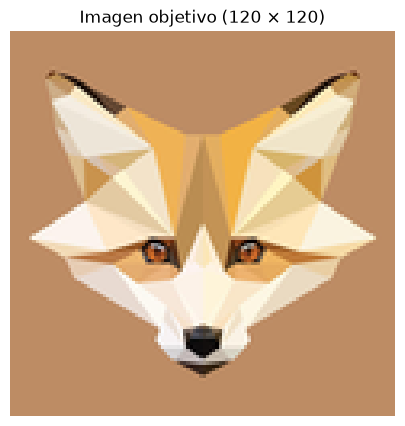

In [6]:
# Ruta local de la imagen que se desea aproximar.
INPUT_IMAGE = Path("test_fox.jpg")
OUTPUT_IMAGE = Path("reconstruccion_final.png")

# Parámetros ajustables.
TARGET_SIZE = 120       # Resolución utilizada durante la evolución.
K = 500                 # Número de triángulos.
N = 50                  # Tamaño de la población.
G = 200                 # Número máximo de generaciones.
PM = 0.20               # Probabilidad de mutación.
PC = 0.80               # Probabilidad de crossover.
ELITE = 5               # Cantidad de individuos élite.
STOP_ERROR = 0.001
PACIENCIA = 30

if not INPUT_IMAGE.is_file():
    raise FileNotFoundError(
        f"No se encontró la imagen: {INPUT_IMAGE.resolve()}. "
        "Modifica INPUT_IMAGE para apuntar a un archivo JPG o PNG existente."
    )

img_original = Image.open(INPUT_IMAGE).convert("RGB")
target = img_original.resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.LANCZOS)

plt.figure(figsize=(5, 5))
plt.imshow(target)
plt.title(f"Imagen objetivo ({TARGET_SIZE} × {TARGET_SIZE})")
plt.axis("off")
plt.show()


## 6. Ejecución del algoritmo

Se construye el algoritmo, se configura el método de selección y se inicia la evolución. También se pueden probar `elite`, `ruleta`, `universal`, `boltzmann`, `torneo_det` o `torneo_prob`.


In [7]:
print("--- EJECUTANDO ALGORITMO GENÉTICO MEJORADO ---")

ag = AG_Mejorado(
    target,
    K,
    pop=N,
    gens=G,
    pm=PM,
    pc=PC,
    elite=ELITE,
    stop_error=STOP_ERROR,
    modo_supervivencia="exclusiva",  # También puede usarse "aditiva".
    paciencia=PACIENCIA,
    eval_size_inicial=40,
    eval_size_final=100,
)
ag.set_seleccion("ranking", presion=1.5)

best, err, hist, mejor_cada = ag.run()
print(f"Error final (evaluación progresiva): {err:.6f}")


--- EJECUTANDO ALGORITMO GENÉTICO MEJORADO ---
Estancamiento detectado en generación 29 (sin mejora durante 30 gens)
Tiempo total: 9.9 s
Error final (evaluación progresiva): 0.141183


## 7. Refinamiento local

El mejor individuo se pule mediante *hill climbing* a una resolución de evaluación más alta.


In [8]:
print("--- REFINANDO CON HILL CLIMBING ---")

best_refinado, err_refinado = ag.hill_climbing(
    best,
    iteraciones=2,
    paso_inicial=0.03,
    size_eval=100,
)
print(f"Error después del hill climbing: {err_refinado:.6f}")


--- REFINANDO CON HILL CLIMBING ---
Error después del hill climbing: 0.069747


## 8. Renderizado final

La reconstrucción conserva la relación de aspecto original, limita el lado mayor a 500 píxeles y utiliza supersampling para suavizar los bordes.


In [9]:
max_dim = 500
w_orig, h_orig = img_original.size

if max(w_orig, h_orig) > max_dim:
    factor = max_dim / max(w_orig, h_orig)
    final_size = (int(w_orig * factor), int(h_orig * factor))
else:
    final_size = (w_orig, h_orig)

print(f"Renderizando a {final_size[0]} × {final_size[1]} con antialiasing...")
tri_final = ag.genes_a_triangulos(best_refinado)
reconstructed_high = renderizar_alta_resolucion(
    tri_final,
    size=final_size,
    supersample=2,
)
reconstructed_eval = renderizar(tri_final, size=(TARGET_SIZE, TARGET_SIZE))


Renderizando a 500 × 500 con antialiasing...


## 9. Resultados

Se comparan la imagen objetivo, las reconstrucciones y la evolución del error.


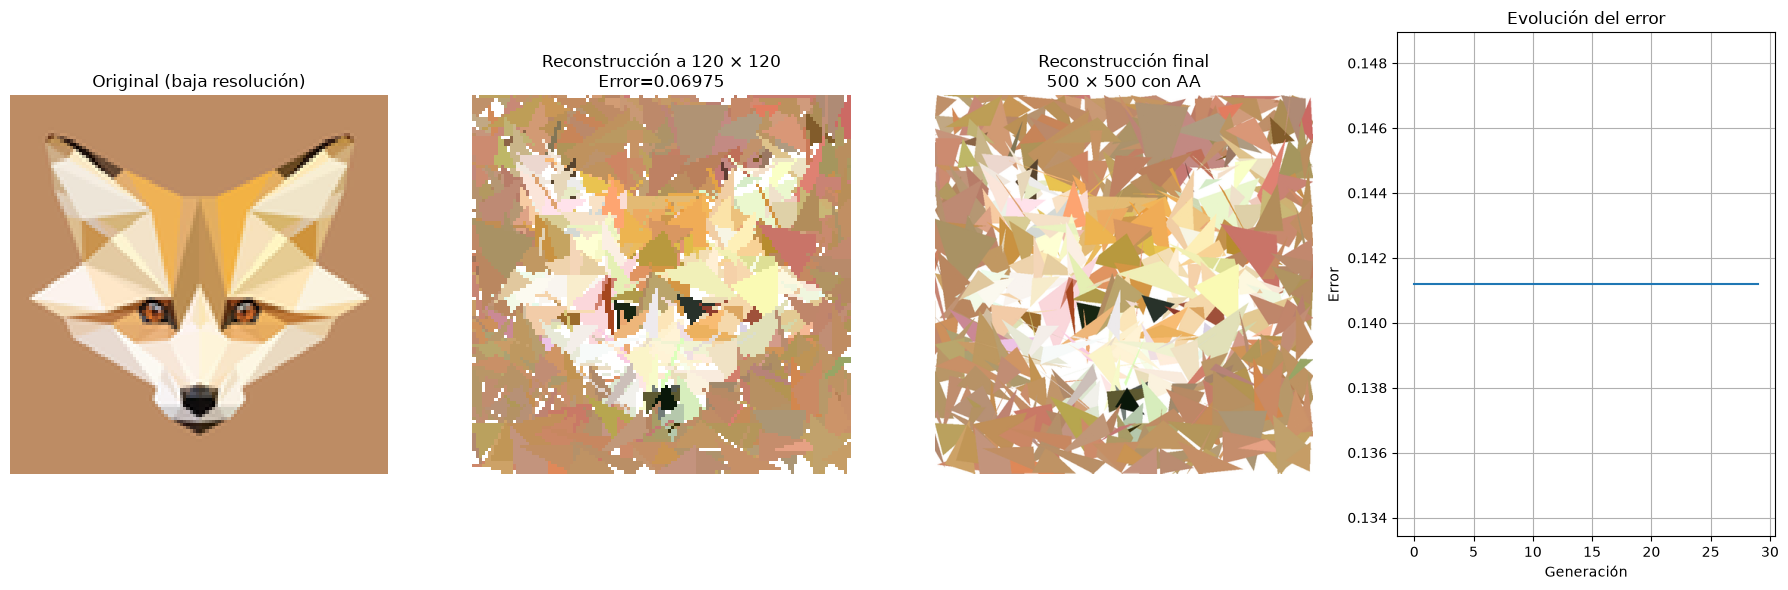

In [10]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(target)
plt.title("Original (baja resolución)")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(reconstructed_eval)
plt.title(f"Reconstrucción a {TARGET_SIZE} × {TARGET_SIZE}\nError={err_refinado:.5f}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(reconstructed_high)
plt.title(f"Reconstrucción final\n{final_size[0]} × {final_size[1]} con AA")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.plot(hist)
plt.title("Evolución del error")
plt.xlabel("Generación")
plt.ylabel("Error")
plt.grid(True)

plt.tight_layout()
plt.show()


### Evolución intermedia

Se muestran hasta diez estados intermedios registrados durante la evolución.


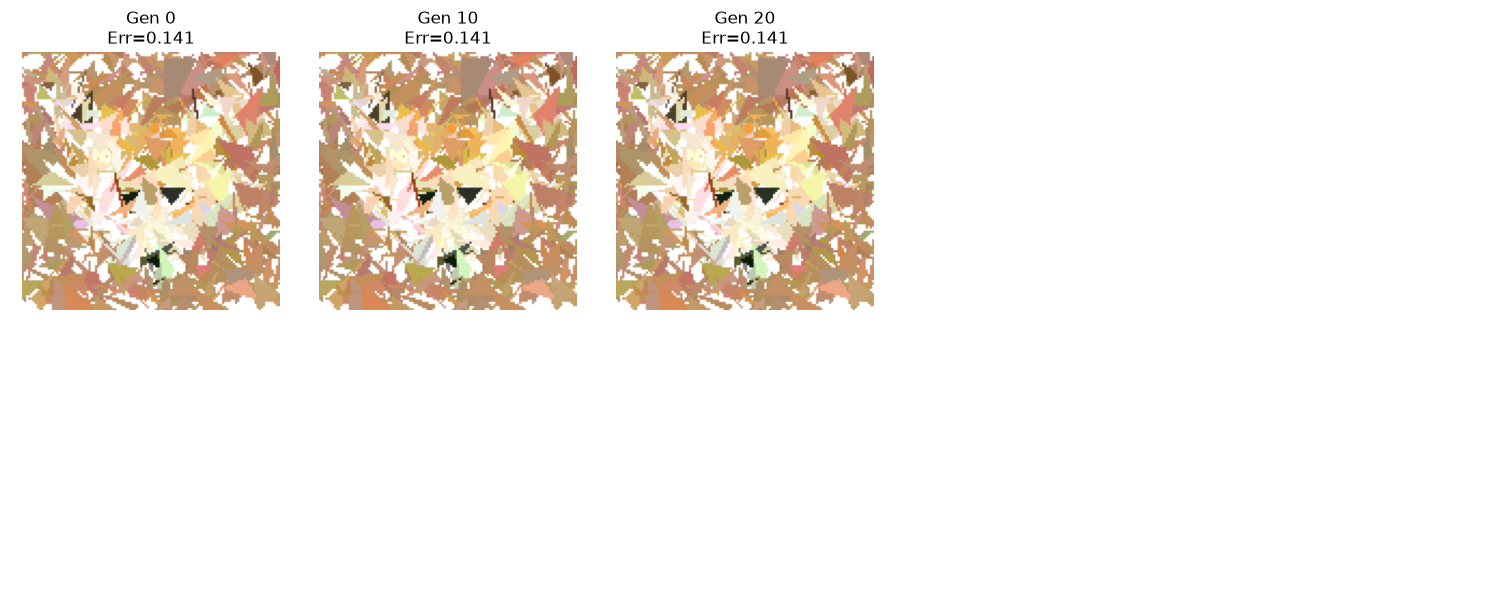

In [11]:
if len(mejor_cada) > 1:
    muestras = mejor_cada[:10]
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, (gen, error_gen, individuo) in zip(axes, muestras):
        tri_tmp = ag.genes_a_triangulos(individuo)
        img_tmp = renderizar(tri_tmp, size=(TARGET_SIZE, TARGET_SIZE))
        ax.imshow(img_tmp)
        ax.set_title(f"Gen {gen}\nErr={error_gen:.3f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 10. Inspección y guardado

Finalmente se imprimen los primeros diez triángulos y se guarda la reconstrucción en la ruta indicada por `OUTPUT_IMAGE`.


In [12]:
print("--- TRIÁNGULOS FINALES (PRIMEROS 10) ---")
for i, (pts, color) in enumerate(tri_final[:10], start=1):
    print(
        f"{i}: vértices=({pts[0]:.3f}, {pts[1]:.3f}) "
        f"({pts[2]:.3f}, {pts[3]:.3f}) ({pts[4]:.3f}, {pts[5]:.3f}) "
        f"color=({color[0]:.3f}, {color[1]:.3f}, {color[2]:.3f}, {color[3]:.3f})"
    )

restantes = max(0, len(tri_final) - 10)
print(f"... y {restantes} triángulos más.")

reconstructed_high.save(OUTPUT_IMAGE)
print(f"Imagen final guardada en: {OUTPUT_IMAGE.resolve()}")


--- TRIÁNGULOS FINALES (PRIMEROS 10) ---
1: vértices=(0.007, 0.000) (0.058, 0.011) (0.000, 0.062) color=(0.742, 0.556, 0.394, 0.963)
2: vértices=(0.074, 0.065) (0.109, 0.032) (0.000, 0.106) color=(0.746, 0.558, 0.398, 1.000)
3: vértices=(0.089, 0.000) (0.059, 0.000) (0.162, 0.094) color=(0.691, 0.597, 0.396, 0.905)
4: vértices=(0.024, 0.000) (0.180, 0.000) (0.229, 0.019) color=(0.745, 0.636, 0.373, 1.000)
5: vértices=(0.119, 0.000) (0.099, 0.025) (0.244, 0.000) color=(0.769, 0.576, 0.412, 1.000)
6: vértices=(0.196, 0.000) (0.255, 0.038) (0.123, 0.113) color=(0.791, 0.585, 0.334, 0.995)
7: vértices=(0.264, 0.037) (0.387, 0.017) (0.213, 0.000) color=(0.762, 0.533, 0.356, 0.973)
8: vértices=(0.353, 0.000) (0.348, 0.000) (0.340, 0.000) color=(0.766, 0.548, 0.426, 1.000)
9: vértices=(0.388, 0.000) (0.319, 0.000) (0.380, 0.076) color=(0.789, 0.535, 0.348, 0.832)
10: vértices=(0.343, 0.000) (0.409, 0.000) (0.413, 0.014) color=(0.784, 0.418, 0.406, 0.888)
... y 490 triángulos más.
Imagen final